# Stereo System from Single Camera by Translation of 10cm

In [1]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
import open3d as o3d 

## Camera Calibration

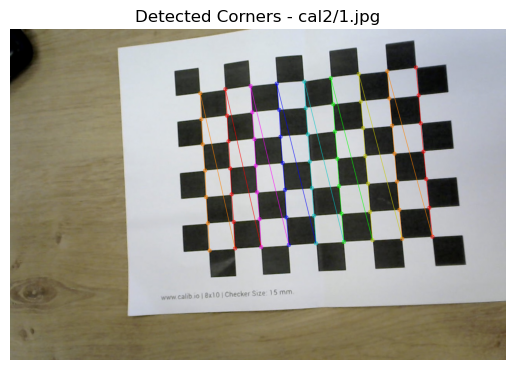

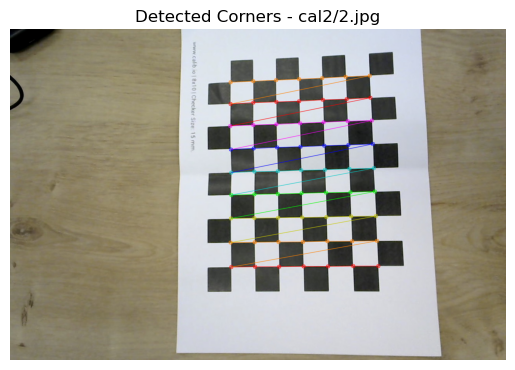

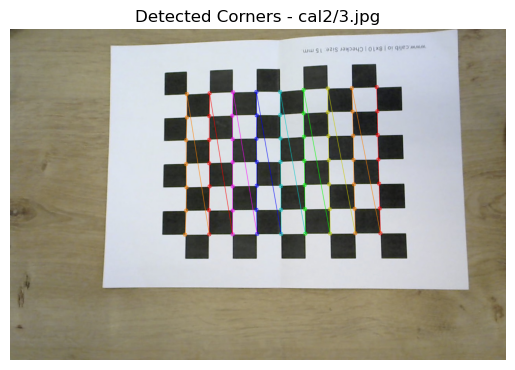

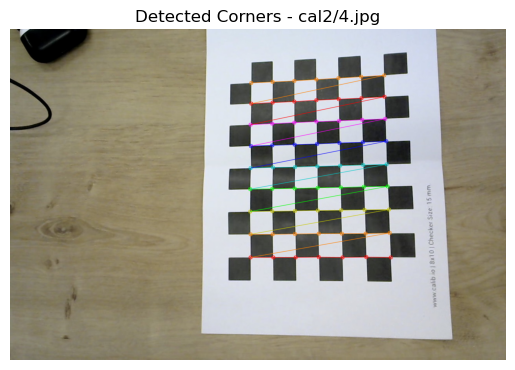

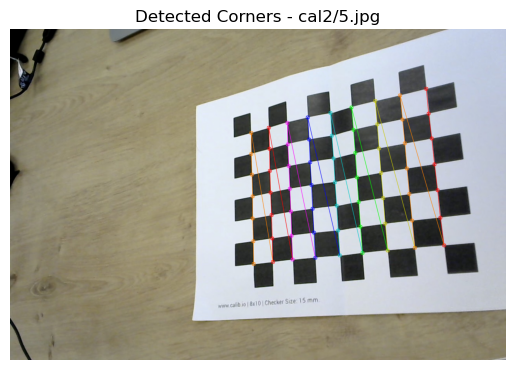

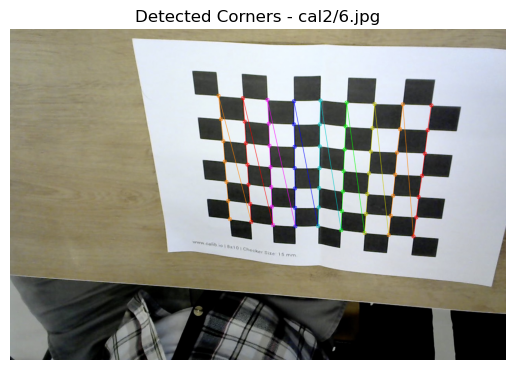

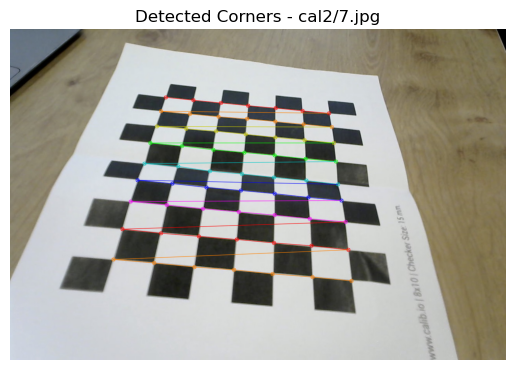

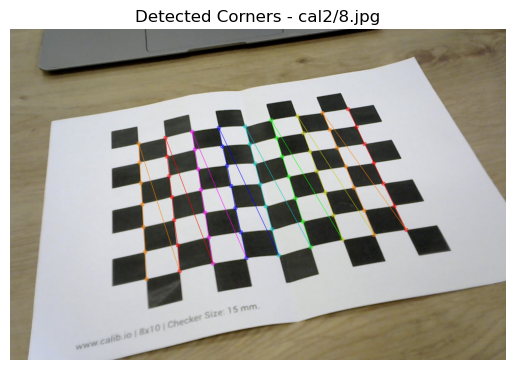

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define chessboard size 
chessboard_size = (7, 9)  # (Columns, Rows) - Change if needed
square_size = 15.0  # Square Size = 15mm 

# Prepare object points (3D points of chessboard corners in real-world)
objp = np.zeros((chessboard_size[0] * chessboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2) * square_size

# Lists to store 3D points (object points) and 2D points (image points)
objpoints = []  # Real-world points
imgpoints = []  # Image points (detected corners)

# List of calibration images (jpg format)
image_paths = ["cal2/1.jpg","cal2/2.jpg","cal2/3.jpg","cal2/4.jpg","cal2/5.jpg","cal2/6.jpg","cal2/7.jpg","cal2/8.jpg",]

# Read and process each calibration image
for img_path in image_paths:
    img = cv2.imread(img_path)   #Reads the image from the specified path
    
    if img is None:
        print(f"Error: Could not load {img_path}")
        continue
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    
    # Detect chessboard corners
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None) # Detects the corners of a chessboard pattern, 
    #gray: The grayscale input image.
    #chessboard_size: The number of inner corners per chessboard row and column.

    #Reutrns of the functions are as follows: 

    #ret: Boolean indicating success (True) or failure (False) in detecting the chessboard.
    #corners: Detected corner positions (if found).

    
    if ret:
        objpoints.append(objp)
        imgpoints.append(corners)

        # Draw and display the corners
        cv2.drawChessboardCorners(img, chessboard_size, corners, ret) # Draws detected chessboard corners on an image.
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Displays an image using Matplotlib.
        plt.title(f"Detected Corners - {img_path}")
        plt.axis("off")
        plt.show()
    else:
        print(f"Chessboard not detected in {img_path}")


# Intrinsic Parameters & Distortion Coefficients

In [3]:
# Performed camera calibration
if len(objpoints) > 0 and len(imgpoints) > 0:
    ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None) #Computes the intrinsic parameters
    #(camera matrix K) and extrinsic parameters (rotation and translation vectors) of the camera. 

    #objpoints: 3D real-world coordinates of chessboard corners.
    #imgpoints: 2D image coordinates of detected corners.
    #gray.shape[::-1]: Image size in (width, height) format.
    #None, None: The initial guess for cameraMatrix and distCoeffs (optional).

    #ret: The RMS (Root Mean Square) re-projection error, indicating calibration accuracy.
    #K: The intrinsic matrix (camera matrix).
    #dist: The distortion coefficients (to correct lens distortion).
    #rvecs: Rotation vectors for each calibration image.
    #tvecs: Translation vectors for each calibration image.



    print("Intrinsic Matrix (K):\n", K)
    print("\nDistortion Coefficients:\n", dist)

    # Computed reprojection error
    reprojection_error = 0
    for i in range(len(objpoints)):
        imgpoints2, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, dist) # Reprojects 3D world points (objectPoints) back into 2D image space using the computed camera parameters. 
        error = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)    # Computes the difference (error) between two sets of points using the L2 norm (Euclidean distance). 

        reprojection_error += error
    reprojection_error /= len(objpoints)

    print("\nReprojection Error:", reprojection_error)

else:
    print("Calibration failed: No valid chessboard detections.")


Intrinsic Matrix (K):
 [[1.55593613e+03 0.00000000e+00 7.56076066e+02]
 [0.00000000e+00 1.56149035e+03 4.97557879e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients:
 [[ 2.51602510e-01 -3.20063051e+00  1.83156042e-02  1.08366488e-02
   1.58031826e+01]]

Reprojection Error: 0.26538355416644765


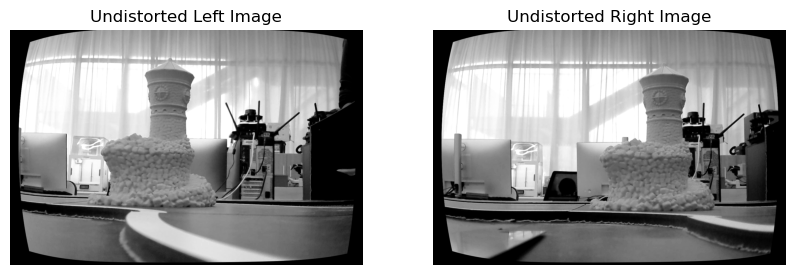

In [4]:
# Loading left and right images
left_img = cv2.imread("cal2/left.jpg")
right_img = cv2.imread("cal2/right.jpg")

# Convert to grayscale
left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

# Undistort images
undistorted_left = cv2.undistort(left_gray, K, dist) # Removes distortion from an image using a precomputed camera matrix (K) and distortion coefficients.Corrects radial and tangential distortions caused by the camera lens, ensuring straight lines remain straight.
undistorted_right = cv2.undistort(right_gray, K, dist)

# Display the undistorted images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(undistorted_left, cmap="gray")
plt.title("Undistorted Left Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(undistorted_right, cmap="gray")
plt.title("Undistorted Right Image")
plt.axis("off")

plt.show()


## Rectification

In [5]:
def rectify_images(img_left, img_right, K_left, D_left, K_right, D_right, transform):
    """
    Performs stereo image rectification using intrinsic parameters and a known transform.
    
    Parameters:
        img_left, img_right : input stereo images
        K_left, D_left      : intrinsics and distortion for left camera
        K_right, D_right    : intrinsics and distortion for right camera
        transform           : 4x4 transformation matrix [R|t]
    
    Returns:
        Rectified left and right images, and the disparity-to-depth matrix Q
    """
    # Decompose transformation matrix into rotation and translation components
    R = transform[:3, :3]
    t = transform[:3, 3]

    # Compute rectification transforms and projection matrices
    R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(
        K_left, D_left, K_right, D_right,
        img_left.shape[:2][::-1], R, t,
        flags=cv2.CALIB_ZERO_DISPARITY, alpha=1
    )

    print("\nProjection 1\n", P1)
    print("\nProjection 2\n", P2)

    # Generate remapping matrices for both images
    map1_x, map1_y = cv2.initUndistortRectifyMap(K_left, D_left, R1, P1, img_left.shape[:2][::-1], cv2.CV_32FC1)
    map2_x, map2_y = cv2.initUndistortRectifyMap(K_right, D_right, R2, P2, img_right.shape[:2][::-1], cv2.CV_32FC1)

    # Apply remapping to get rectified images
    rectified_left = cv2.remap(img_left, map1_x, map1_y, cv2.INTER_LINEAR)
    rectified_right = cv2.remap(img_right, map2_x, map2_y, cv2.INTER_LINEAR)

    return rectified_left, rectified_right, Q

def draw_epipolar_lines(image, color=(0, 255, 0), interval=20):
    """
    Overlay horizontal epipolar lines on a given image.

    Parameters:
        image : Input image to annotate
        color : BGR color for the lines
        interval : Vertical spacing between lines

    Returns:
        Image with epipolar lines
    """
    annotated = image.copy()
    height, width = image.shape[:2]
    for y in range(0, height, interval):
        cv2.line(annotated, (0, y), (width, y), color, 1)
    return annotated




Projection 1
 [[1.54789595e+03 0.00000000e+00 7.34654495e+02 0.00000000e+00]
 [0.00000000e+00 1.54789595e+03 4.98136940e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]

Projection 2
 [[1.54789595e+03 0.00000000e+00 7.34654495e+02 1.54789598e+02]
 [0.00000000e+00 1.54789595e+03 4.98136940e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]

Disparity to Depth Maping 'Q' Matrix
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -7.34654495e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -4.98136940e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.54789595e+03]
 [ 0.00000000e+00  0.00000000e+00 -9.99999985e+00  0.00000000e+00]]


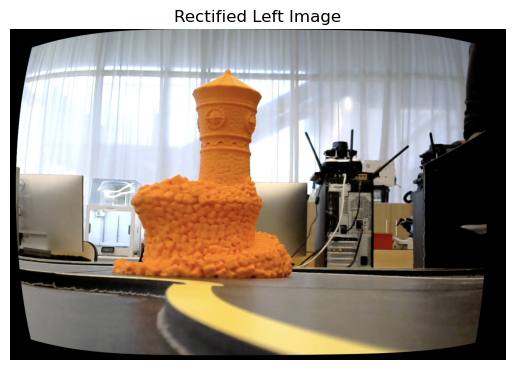

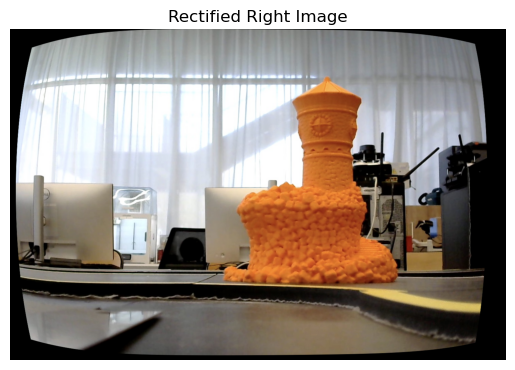

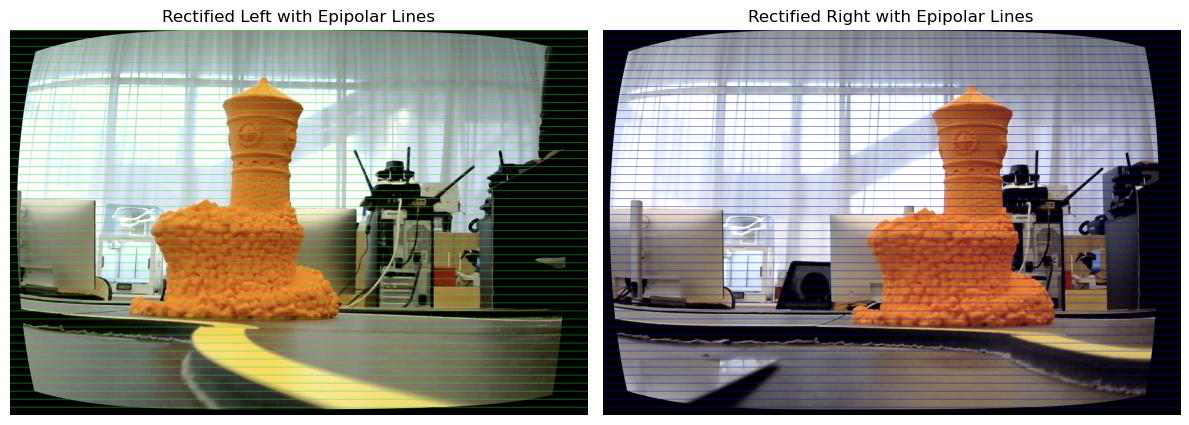

In [15]:
cam_matrix_left = K
dist_coeffs_left = dist

cam_matrix_right = K
dist_coeffs_right = dist


# Load stereo images
img_left = cv2.imread("cal2/left.jpg")
img_right = cv2.imread("cal2/right.jpg")

# Define transformation matrix (only translation in this simplified case)
T = np.eye(4, dtype=np.float32)
T[:3, 3] = np.array([0.10, 0, 0], dtype=np.float32)  # 10 cm baseline along X-axis

# Perform rectification using calibration results from the previous cell
rectified_left, rectified_right, Q = rectify_images(
    img_left, img_right, cam_matrix_left, dist_coeffs_left,
    cam_matrix_right, dist_coeffs_right, T
)

# Display the disparity-to-depth mapping matrix
print("\nDisparity to Depth Maping 'Q' Matrix\n",Q)

# Save rectified images for reference
cv2.imwrite('results_single_camrectified_left.jpg', rectified_left)
cv2.imwrite('results_single_camrectified_right.jpg', rectified_right)

# Visualize rectified images
plt.imshow(cv2.cvtColor(rectified_left, cv2.COLOR_BGR2RGB))
plt.title("Rectified Left Image")
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(rectified_right, cv2.COLOR_BGR2RGB))
plt.title("Rectified Right Image")
plt.axis('off')
plt.show()


# Add epipolar lines for visual verification
epipolar_left = draw_epipolar_lines(rectified_left, color=(0, 255, 0))
epipolar_right = draw_epipolar_lines(rectified_right, color=(255, 0, 0))

# Display epipolar line overlays side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(epipolar_left, cv2.COLOR_BGR2RGB))
plt.title("Rectified Left with Epipolar Lines")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(epipolar_right, cv2.COLOR_BGR2RGB))
plt.title("Rectified Right with Epipolar Lines")
plt.axis('off')

plt.tight_layout()
plt.show()


# Feature Matching & Computing Essential Matrix, Rotation Matrices and Translation Matrix

Total matches found: 2368
Total strong matches after filtering: 2368
Fundamnetal Matrix [[-5.78281324e-23 -5.92572820e-06  3.19424903e-04]
 [ 5.92572820e-06 -5.86483243e-22 -7.44355374e-03]
 [-3.19424903e-04  7.44355374e-03  0.00000000e+00]]
Rank of F: 2


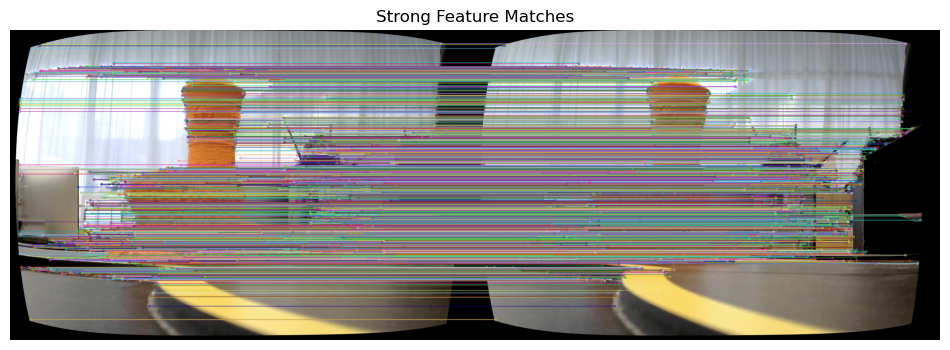

Essential Matrix:
[[-1.39998279e-16 -1.43970263e+01 -4.09050607e+00]
 [ 1.43970263e+01 -1.42999401e-15 -4.62709014e+00]
 [ 4.09050607e+00  4.62709014e+00  4.44089210e-16]]

 Rotation Matrices:


Rotation Matrix R1
 [[ 1.00000000e+00  5.39386497e-18 -9.73260885e-17]
 [-4.95005041e-17  1.00000000e+00 -2.24493464e-17]
 [-2.03852616e-16  5.30622918e-18  1.00000000e+00]]

Rotation Matrix R2
 [[-0.82552145 -0.15424501  0.54288379]
 [-0.15424501 -0.86364213 -0.47992785]
 [ 0.54288379 -0.47992785  0.68916359]]

Translation Vector:

[ 0.29536295 -0.26111096  0.91901131]


In [10]:
# Initialize AKAZE detector and brute-force matcher (Hamming norm is suitable for binary descriptors)
akaze = cv2.AKAZE_create()
bf_matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Detect keypoints and compute descriptors in the rectified stereo images
keypoints_left, descriptors_left = akaze.detectAndCompute(rectified_left, None)
keypoints_right, descriptors_right = akaze.detectAndCompute(rectified_right, None)

# Match descriptors between the two images using brute-force matcher
initial_matches = bf_matcher.match(descriptors_left, descriptors_right)

# Sort matches based on descriptor distance (lower = better)
initial_matches = sorted(initial_matches, key=lambda x: x.distance)

# Filter out weak matches using a distance threshold
threshold = 100  # Matches with distance < threshold are considered strong
strong_matches = [m for m in initial_matches if m.distance < threshold]

# Display match statistics
print(f"Total matches found: {len(initial_matches)}")
print(f"Total strong matches after filtering: {len(strong_matches)}")

# Extract coordinates of matched keypoints
points_left = np.float32([keypoints_left[m.queryIdx].pt for m in strong_matches]).reshape(-1, 1, 2)
points_right = np.float32([keypoints_right[m.trainIdx].pt for m in strong_matches]).reshape(-1, 1, 2)

# Estimate the Fundamental matrix using RANSAC and filter inliers
F, inlier_mask = cv2.findFundamentalMat(points_left, points_right, cv2.FM_RANSAC, ransacReprojThreshold=3)
print('Fundamnetal Matrix', F)
print("Rank of F:", np.linalg.matrix_rank(F))

# Extract only inlier matches based on the mask
points_left_inliers = points_left[inlier_mask.ravel() == 1]
points_right_inliers = points_right[inlier_mask.ravel() == 1]

# Visualize matches with inliers highlighted
matched_image = cv2.drawMatches(
    rectified_left, keypoints_left, rectified_right, keypoints_right,
    strong_matches, None, matchesMask=inlier_mask.ravel().tolist(),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Display the result
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.title("Strong Feature Matches")
plt.axis("off")
plt.show()

# Save the image with matched inliers
cv2.imwrite("strong_feature_matches_with_ransac.jpg", matched_image)

# Compute the Essential matrix using the known intrinsic camera matrix
E = cam_matrix_left.T @ F @ cam_matrix_left
print("Essential Matrix:")
print(E)

# Decompose the Essential matrix to retrieve rotation and translation (up to scale)
U, S, Vt = np.linalg.svd(E)
W = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1]])

# Two possible rotation matrices
R1_candidate = U @ W @ Vt
R2_candidate = U @ W.T @ Vt
translation_vector = U[:, 2]

# Output possible motion configurations
print("\n Rotation Matrices:\n")
print("\nRotation Matrix R1\n", R1_candidate)
print("\nRotation Matrix R2\n",R2_candidate)
print("\nTranslation Vector:\n")
print(translation_vector)


## Aplying Checks

In [11]:
# Perform Singular Value Decomposition on the Essential matrix
U, S, Vt = np.linalg.svd(E)
print(f"Singular values of E: {S}")

# Validate the rank condition of the Essential matrix
if np.isclose(S[2], 0, atol=1e-5):
    print("Essential matrix has the correct rank (2).")
else:
    print("Essential matrix does NOT have the correct rank!")

# Check the determinant condition of the Essential matrix
det_E = np.linalg.det(E)
print(f"Det(E) = {det_E}")
if np.isclose(det_E, 0, atol=1e-5):
    print("Essential matrix satisfies det(E) = 0 condition.")
else:
    print("Essential matrix does NOT satisfy det(E) = 0 condition!")

# Verify that candidate rotation matrices are valid (determinant should be +1)
det_R1 = np.linalg.det(R1_candidate)
det_R2 = np.linalg.det(R2_candidate)
print(f"Det(R1) = {det_R1}, Det(R2) = {det_R2}")


Singular values of E: [1.56657770e+01 1.56657770e+01 2.09500137e-16]
Essential matrix has the correct rank (2).
Det(E) = 6.617101380840726e-14
Essential matrix satisfies det(E) = 0 condition.
Det(R1) = 1.0, Det(R2) = 1.0000000000000004


## Triangulation

In [12]:
# Reuse cam_matrix_left as K (intrinsic matrix from left camera calibration)
K = cam_matrix_left

# Reuse decomposed essential matrix components
R1 = R1_candidate
R2 = R2_candidate
T = translation_vector

import cv2
import numpy as np

# Camera intrinsic matrix (replace with actual values)
K  # Replace with actual intrinsic matrix

# Essential matrix and decomposed values
E  
R1  
R2  
T  
# Check and fix T
print("Original T shape:", T.shape)
if T.shape == (3,):
    T = T.reshape(3, 1)
print("Fixed T shape:", T.shape)

# Choose the correct rotation matrix (closest to identity)
identity_matrix = np.eye(3)
R1_deviation = np.linalg.norm(R1 - identity_matrix)
R2_deviation = np.linalg.norm(R2 - identity_matrix)

if R1_deviation < R2_deviation:
    R = R1
    print("Selected R1")
else:
    R = R2
    print("Selected R2")

# Compute projection matrices
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))  # P1 = K [I | 0]
P2 = K @ np.hstack((R, T))  # P2 = K [R | T]

# Ensure points_left_inliers and points_right_inliers are 2D
print("points_left_inliers shape before reshape:", points_left_inliers.shape)
print("points_right_inliers shape before reshape:", points_right_inliers.shape)

if points_left_inliers.ndim == 3:
    points_left_inliers = points_left_inliers.reshape(-1, 2)
if points_right_inliers.ndim == 3:
    points_right_inliers = points_right_inliers.reshape(-1, 2)

# Convert points to homogeneous coordinates
points_left_inliers_hom = np.vstack((points_left_inliers.T, np.ones((1, points_left_inliers.shape[0]))))  # Shape: (3, N)
points_right_inliers_hom = np.vstack((points_right_inliers.T, np.ones((1, points_right_inliers.shape[0]))))  # Shape: (3, N)

# Perform triangulation
points_4d_hom = cv2.triangulatePoints(P1, P2, points_left_inliers_hom[:2], points_right_inliers_hom[:2])

# Convert from homogeneous to 3D coordinates
points_3d = points_4d_hom[:3] / points_4d_hom[3]  # Shape: (3, N)

# Filter out points with negative depth (Z should be positive)
valid_indices = points_3d[2] > 0
points_3d_filtered = points_3d[:, valid_indices]

# Print results
print("Reconstructed 3D Points (filtered):")
print(points_3d_filtered.T)  # Shape: (valid_N, 3)



Original T shape: (3,)
Fixed T shape: (3, 1)
Selected R1
points_left_inliers shape before reshape: (2368, 1, 2)
points_right_inliers shape before reshape: (2368, 1, 2)
Reconstructed 3D Points (filtered):
[[ 3.66149195e+14 -2.87935789e+14  9.85837455e+14]
 [-2.20922788e+14 -7.71982529e+14  3.21792479e+15]
 [-1.34926076e+15 -7.22582976e+14  3.09128953e+15]
 ...
 [ 2.00549728e+15 -3.16575308e+14  2.43592098e+16]
 [-1.37135557e+15  2.18721332e+14  5.19727329e+15]
 [-1.33845128e+15  3.19788640e+14  5.20206009e+15]]


## Point Cloud

In [13]:
import open3d as o3d

# Load your point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_3d.T)  # Convert numpy to Open3D format

# Apply statistical outlier removal
pcd_filtered, ind = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# Visualize before and after
o3d.visualization.draw_geometries([pcd], window_name="Noisy Point Cloud")
# o3d.visualization.draw_geometries([pcd_filtered], window_name="Filtered Point Cloud")

## Reprojection to Original Image

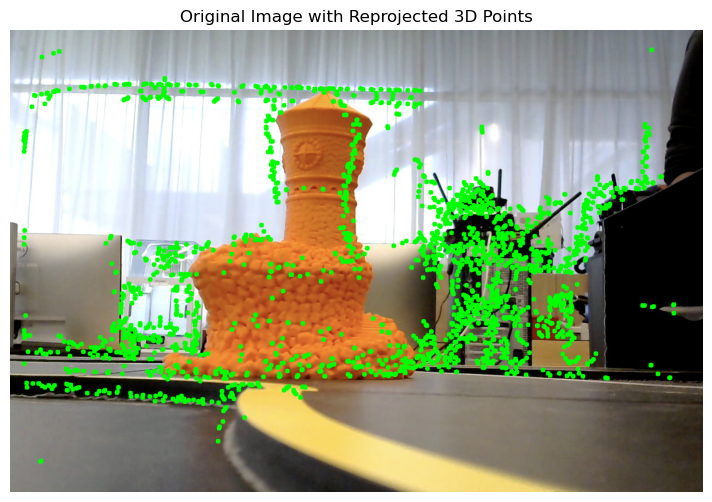

In [14]:


# Assuming you already have the following:
# - points_3d: Reconstructed 3D points (shape: 3xN)
# - K: Camera intrinsic matrix
# - R, T: Rotation and translation between the two cameras
# - img1: Original first image (before rectification)

# Step 1: Define the projection matrix for the first camera
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))  # P1 = K [I | 0]

# Step 2: Reproject 3D points onto the first image
points_4d_hom = np.vstack((points_3d, np.ones((1, points_3d.shape[1]))))  # Convert to homogeneous coordinates
reprojected_pts = P1 @ points_4d_hom  # Project to 2D
reprojected_pts = reprojected_pts[:2] / reprojected_pts[2]  # Normalize to get (u, v) coordinates


# Step 3: Visualize the reprojected points on the original image
img1_with_points = img_left.copy()  # Make a copy of the original image

# Draw the reprojected points on the image
for pt in reprojected_pts.T:
    u, v = int(pt[0]), int(pt[1])  # Convert to integer pixel coordinates
    cv2.circle(img1_with_points, (u, v), radius=5, color=(0, 255, 0), thickness=-1)  # Green points

# Display the image with reprojected points
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img1_with_points, cv2.COLOR_BGR2RGB))
plt.title("Original Image with Reprojected 3D Points")
plt.axis('off')
plt.show()